In [239]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [240]:
df = pd.read_parquet("/Users/YGT/ist-airport-decision-support-system/data/silver/trajectories/trajectory_all.parquet")

In [241]:
df.head()

,hex,icao,date,trajectory_timestamp,point_timestamp,latitude,longitude,altitude_baro,ground_speed,track,baro_rate,nav_altitude_mcp,distance_km,on_ground
0,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:30:57+00:00,40.97,28.55,3075.00,232.00,101.90,NaN,3250.00,38.21,False
1,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:31:01+00:00,40.96,28.56,3075.00,229.50,101.30,-64.00,3250.00,38.10,False
2,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:33:50+00:00,41.03,28.71,3075.00,200.00,359.40,NaN,3250.00,27.07,False
3,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:03+00:00,41.05,28.71,3075.00,188.00,0.60,NaN,3250.00,25.74,False
4,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:07+00:00,41.05,28.71,3075.00,182.00,359.70,NaN,3250.00,25.37,False


In [242]:
df = df[["icao", "date", "trajectory_timestamp", "point_timestamp",	"latitude",	"longitude", "altitude_baro" ,"distance_km", "on_ground"]]

In [243]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31844737 entries, 0 to 31844736
Data columns (total 9 columns):
 #   Column                Dtype              
---  ------                -----              
 0   icao                  str                
 1   date                  str                
 2   trajectory_timestamp  datetime64[ms, UTC]
 3   point_timestamp       datetime64[ms, UTC]
 4   latitude              float32            
 5   longitude             float32            
 6   altitude_baro         float32            
 7   distance_km           float32            
 8   on_ground             bool               
dtypes: bool(1), datetime64[ms, UTC](2), float32(4), str(2)
memory usage: 1.9 GB


In [244]:
df.isna().sum()

icao                       0
date                       0
trajectory_timestamp       0
point_timestamp            0
latitude                   0
longitude                  0
altitude_baro           4332
distance_km                0
on_ground                  0
dtype: int64

In [245]:
df = df.sort_values(["icao", "point_timestamp"])

## Duplicate Data Control

In [ ]:
df.duplicated(
    subset=[
        "icao",
        "point_timestamp",
        "latitude",
        "longitude",
        "altitude_baro"
    ]
).sum()

In [ ]:
df = df.drop_duplicates(
    subset=[
        "icao",
        "point_timestamp",
        "latitude",
        "longitude",
        "altitude_baro"
    ],
    keep="first"
)

In [ ]:
check = (
    df.groupby("icao")["point_timestamp"]
      .apply(lambda x: (x.diff().dt.total_seconds() < 0).any())
)

check.sum()

np.int64(0)

## Missing Value Analysis

## Altitude Baro Handling

In [ ]:
on_ground_missing = df.loc[df["on_ground"] == True,  "altitude_baro"].isna().sum()
on_air_missing    = df.loc[df["on_ground"] == False, "altitude_baro"].isna().sum()

print(f"On ground — missing altitude: {on_ground_missing:,}")
print(f"In air    — missing altitude: {on_air_missing:,}")


On ground — missing altitude: 0
In air    — missing altitude: 4,254


In [ ]:
df['altitude_baro'].isna().mean()

np.float64(0.00013367958461661596)

In [ ]:
df['altitude_baro'].describe()

count   31818107.00
mean       16269.67
std        12508.29
min         -900.00
25%         5125.00
50%        11900.00
75%        26825.00
max        81700.00
Name: altitude_baro, dtype: float64

In [ ]:
df = df.dropna(subset=['altitude_baro'])

## Transform Positional Features  Into ENU Coordinates

In [ ]:
df['altitude_m'] = df['altitude_baro'] * 0.3048

In [ ]:
df['altitude_m'].describe()

count   31818107.00
mean        4958.99
std         3812.53
min         -274.32
25%         1562.10
50%         3627.12
75%         8176.26
max        24902.16
Name: altitude_m, dtype: float64

In [ ]:
count_high = (df["altitude_m"] > 13500).sum()

ratio_high = count_high / len(df) * 100

print("higher than 13500m :", count_high)
print("Ratio (%):", ratio_high)

higher than 13500m : 22379
Ratio (%): 0.07033416538576603


In [ ]:
df = df[
    ~(
        (df["altitude_m"] > 13500) &
        (df["on_ground"] == False)
    )
]

In [ ]:
df['altitude_m'].describe()

count   31795728.00
mean        4952.76
std         3806.60
min         -274.32
25%         1562.10
50%         3627.12
75%         8153.40
max        13495.02
Name: altitude_m, dtype: float64

In [ ]:
import pymap3d as pm

# IST Airport
IST_LAT = 41.275278
IST_LON = 28.751944
IST_H0  = 99.0


e, n, u = pm.geodetic2enu(
    df['latitude'].values,
    df['longitude'].values,
    df['altitude_m'].values,
    IST_LAT,
    IST_LON,
    IST_H0
)

# append to df
df['east_m']  = e
df['north_m'] = n
df['up_m']    = u

In [ ]:
df[['east_m','north_m','up_m']].describe()

,east_m,north_m,up_m
count,31795728.00,31795728.00,31795728.00
mean,4883.09,-7888.88,4575.79
std,43305.75,39790.76,3634.97
min,-120498.06,-119708.13,-1003.77
25%,-3584.99,-35007.47,1344.23
50%,9638.37,-18371.47,3367.67
75%,32097.08,7579.51,7406.77
max,120463.87,120079.40,13371.27


In [ ]:
df = df.sort_values(['icao', 'point_timestamp'])

## Analysis of Timepoints

In [ ]:
df = df.sort_values(["icao", "point_timestamp"])

In [ ]:
df["dt"] = df.groupby("icao")["point_timestamp"].diff().dt.total_seconds()

In [ ]:
df["dt"].describe()

count   31785377.00
mean        4817.55
std       143843.14
min            0.00
25%            2.00
50%            6.00
75%           13.00
max     27720008.00
Name: dt, dtype: float64

In [ ]:
df["dt"].describe()

count   31785377.00
mean        4817.55
std       143843.14
min            0.00
25%            2.00
50%            6.00
75%           13.00
max     27720008.00
Name: dt, dtype: float64

In [ ]:
for t in range(300, 3600, 300):
    n_flights = (df['dt'] > t).sum()
    print(t, n_flights)

300 817961
600 745723
900 722516
1200 709589
1500 705905
1800 704711
2100 704204
2400 703831
2700 703545
3000 703296
3300 703069


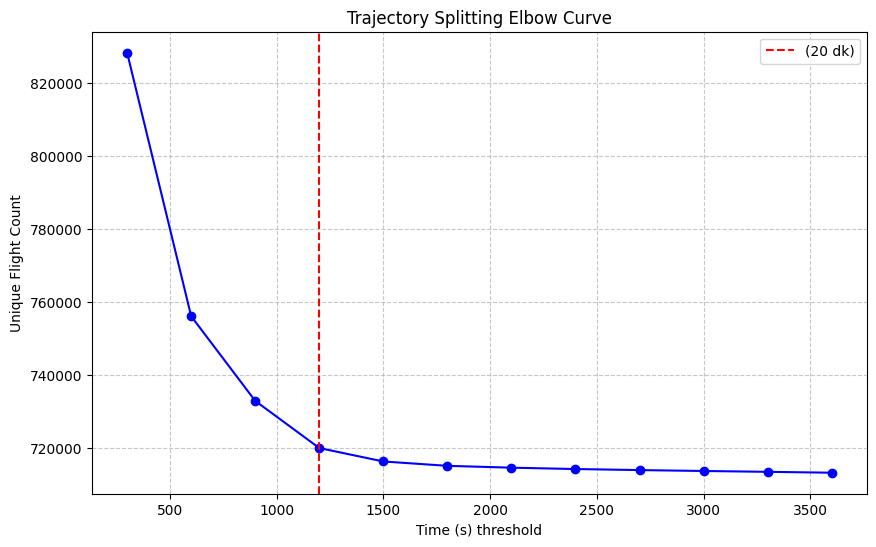

In [ ]:
import matplotlib.pyplot as plt

thresholds = range(300, 3900, 300)
trajectory_counts = []

for t in thresholds:
    n_segments = (df['dt'] > t).sum() + df['icao'].nunique()
    trajectory_counts.append(n_segments)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, trajectory_counts, marker='o', linestyle='-', color='b')
plt.title('Trajectory Splitting Elbow Curve')
plt.xlabel('Time (s)')
plt.ylabel('Unique Flight Count')
plt.grid(True, linestyle='--', alpha=0.7)


plt.axvline(x=1200, color='r', linestyle='--', label='(20 dk)')
plt.legend()

plt.show()

In [ ]:
df['flight_id'] = ((df['icao'] != df['icao'].shift()) | (df['dt'] > 1200) | (df['dt'].isna())).cumsum()

print(f"Flight count: {df['flight_id'].nunique()}")

Flight count: 719940


In [ ]:
flight_sizes = df.groupby('flight_id').size()

print(flight_sizes.describe())

count   719940.00
mean        44.16
std         40.23
min          1.00
25%         15.00
50%         35.00
75%         62.00
max       7762.00
dtype: float64
